# EN3160 Assignment 1 on Intensity Transformations and Neighborhood Filtering

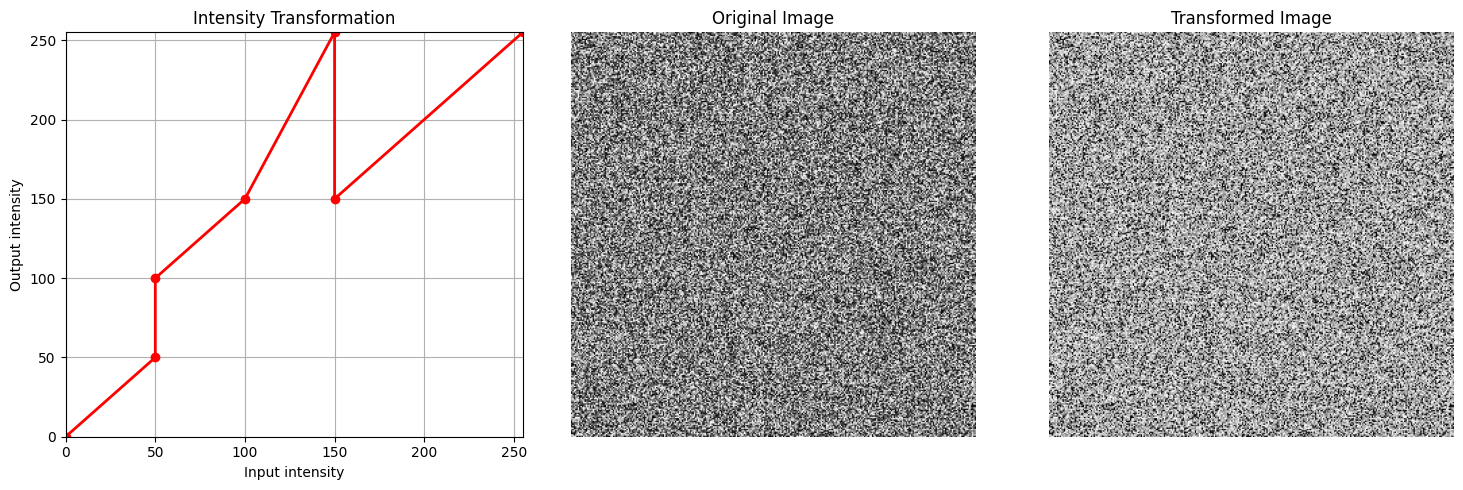

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):

    x_points = breakpoints[:, 0]
    y_points = breakpoints[:, 1]
    
    all_inputs = np.arange(256)
    lut = np.interp(all_inputs, x_points, y_points).astype(np.uint8)
    
    transformed_im = cv2.LUT(im, lut)
    
    return transformed_im

breakpoints_fig1a = np.array([
    [0, 0],
    [50, 50],
    [50, 100],   
    [150, 255],
    [150, 150],
    [255, 255]
], dtype=np.float32)

img = cv2.imread('emma.png', cv2.IMREAD_GRAYSCALE)

if img is None:
    img = np.random.randint(0, 256, (300, 300), dtype=np.uint8)


transformed_img = intensity_transform(img, breakpoints_fig1a)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))


axes[0].plot(breakpoints_fig1a[:, 0], breakpoints_fig1a[:, 1], 'r-o', linewidth=2)
axes[0].set_title("Intensity Transformation")
axes[0].set_xlabel("Input intensity")
axes[0].set_ylabel("Output intensity")
axes[0].set_xlim([0, 255])
axes[0].set_ylim([0, 255])
axes[0].grid(True)

axes[1].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Original Image")

axes[2].imshow(transformed_img, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Transformed Image")

plt.tight_layout()
plt.show()

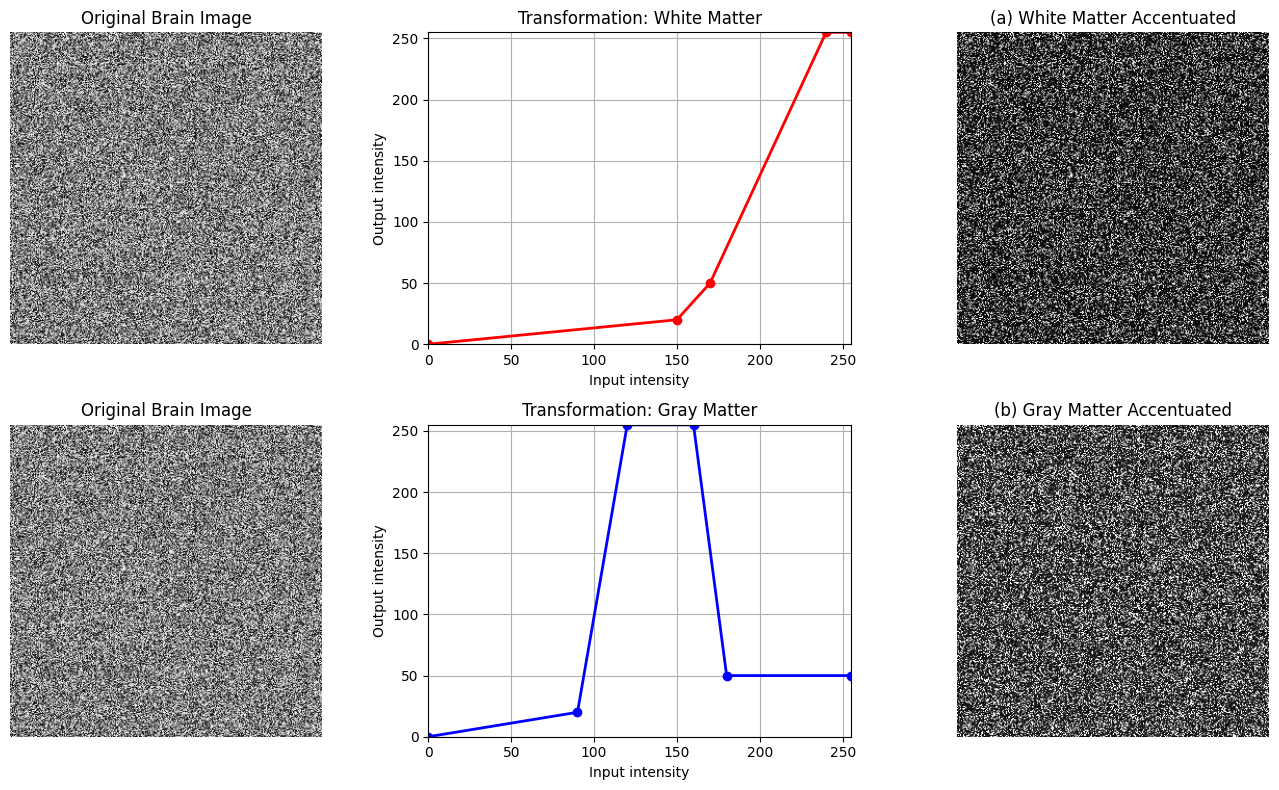

In [ ]:
img = cv2.imread('brain_pd.png', cv2.IMREAD_GRAYSCALE)

if img is None:
    img = np.random.randint(0, 256, (300, 300), dtype=np.uint8)


bp_white_matter = np.array([
    [0, 0],
    [150, 20],  
    [170, 50], 
    [240, 255],  
    [255, 255]
], dtype=np.float32)

bp_gray_matter = np.array([
    [0, 0],
    [90, 20],
    [120, 255], 
    [160, 255],
    [180, 50],   
    [255, 50]
], dtype=np.float32)

img_wm = intensity_transform(img, bp_white_matter)
img_gm = intensity_transform(img, bp_gray_matter)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title("Original Brain Image")
axes[0, 0].axis('off')

axes[0, 1].plot(bp_white_matter[:, 0], bp_white_matter[:, 1], 'r-o', linewidth=2)
axes[0, 1].set_title("Transformation: White Matter")
axes[0, 1].set_xlabel("Input intensity")
axes[0, 1].set_ylabel("Output intensity")
axes[0, 1].set_xlim([0, 255])
axes[0, 1].set_ylim([0, 255])
axes[0, 1].grid(True)

axes[0, 2].imshow(img_wm, cmap='gray', vmin=0, vmax=255)
axes[0, 2].set_title("(a) White Matter Accentuated")
axes[0, 2].axis('off')


axes[1, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title("Original Brain Image")
axes[1, 0].axis('off')

axes[1, 1].plot(bp_gray_matter[:, 0], bp_gray_matter[:, 1], 'b-o', linewidth=2)
axes[1, 1].set_title("Transformation: Gray Matter")
axes[1, 1].set_xlabel("Input intensity")
axes[1, 1].set_ylabel("Output intensity")
axes[1, 1].set_xlim([0, 255])
axes[1, 1].set_ylim([0, 255])
axes[1, 1].grid(True)

axes[1, 2].imshow(img_gm, cmap='gray', vmin=0, vmax=255)
axes[1, 2].set_title("(b) Gray Matter Accentuated")
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()